ya vimos la estructura temporal de los accesos y descubrimos que "crecimiento" no necesariamente significa crecimiento sostenido.
las preguntas que queremos responder viendo lo que nos pudo arrojar los datos durante el proceso de exploración fueron los siguientes:

1. ¿Cómo ha evolucionado la conectividad en Colombia?

  | ¿Cómo ha evolucionado el acceso a internet en Colombia entre 2017 y 2025 y qué tan sostenido ha sido ese crecimiento?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [14]:
from pathlib import Path

ruta = Path("../data/raw")

df1 = pd.read_csv(ruta / "ACCESOS_INTERNET_FIJO_2_8.csv", sep=";")

df2 = pd.read_csv(ruta / "ACCESOS_INTERNET_FIJO_3_5.csv", sep=";")

# Base temporal para comparar el cuarto trimestre de cada año.

df_q4 = df1[df1["TRIMESTRE"] == 4].copy()

accesos_anuales = (

    df1.groupby("ANNO", as_index=False)["ACCESOS"]

    .sum()

)

accesos_q4 = (

    df_q4.groupby("ANNO", as_index=False)["ACCESOS"]

    .sum()

)

accesos_q4["CAMBIO_ABSOLUTO"] = accesos_q4["ACCESOS"].diff()

accesos_q4["CAMBIO_PORCENTUAL"] = accesos_q4["ACCESOS"].pct_change() * 100

residenciales = df1[

    df1["SEGMENTO"].str.startswith("Residencial")

].copy()

residenciales_q4 = residenciales[

    residenciales["TRIMESTRE"] == 4

].copy()

estrato_q4 = (

    residenciales_q4

    .groupby(["ANNO", "SEGMENTO"], as_index=False)["ACCESOS"]

    .sum()

)

estrato_pivot = estrato_q4.pivot(

    index="ANNO", columns="SEGMENTO", values="ACCESOS"

)

cambio_estrato = pd.DataFrame({

    "accesos_2017": estrato_pivot.loc[2017],

    "accesos_2025": estrato_pivot.loc[2025]

})

cambio_estrato["cambio_absoluto"] = (

    cambio_estrato["accesos_2025"] - cambio_estrato["accesos_2017"]

)

cambio_estrato["cambio_%"] = (

    cambio_estrato["accesos_2025"] / cambio_estrato["accesos_2017"] - 1

) * 100

municipal_q4 = (

    residenciales_q4

    .groupby(

        [

            "ID_MUNICIPIO",

            "MUNICIPIO",

            "ID_DEPARTAMENTO",

            "DEPARTAMENTO",

            "ANNO"

        ],

        as_index=False

    )["ACCESOS"]

    .sum()

)

municipios_pivot = (

    municipal_q4

    .pivot_table(

        index=[

            "ID_MUNICIPIO",

            "MUNICIPIO",

            "ID_DEPARTAMENTO",

            "DEPARTAMENTO"

        ],

        columns="ANNO",

        values="ACCESOS",

        fill_value=0

    )

    .reset_index()

)

municipios_pivot.columns.name = None

municipios_pivot = municipios_pivot.rename(

    columns={2017: "ACCESOS_2017", 2025: "ACCESOS_2025"}

)

ranking_municipios = municipios_pivot[

    (municipios_pivot["ACCESOS_2017"] > 0)

    & (municipios_pivot["ACCESOS_2025"] > 0)

].copy()

ranking_municipios["CAMBIO_ABSOLUTO"] = (

    ranking_municipios["ACCESOS_2025"] - ranking_municipios["ACCESOS_2017"]

)

ranking_municipios["CAMBIO_%"] = (

    ranking_municipios["CAMBIO_ABSOLUTO"]

    / ranking_municipios["ACCESOS_2017"]

) * 100

top_crecimiento = (

    ranking_municipios.sort_values("CAMBIO_%", ascending=False)

    [[

        "MUNICIPIO", "DEPARTAMENTO", "ACCESOS_2017", "ACCESOS_2025",

        "CAMBIO_ABSOLUTO", "CAMBIO_%"

    ]]

    .head(20)

)

top_absoluto = (

    ranking_municipios.sort_values("CAMBIO_ABSOLUTO", ascending=False)

    [[

        "MUNICIPIO", "DEPARTAMENTO", "ACCESOS_2017", "ACCESOS_2025",

        "CAMBIO_ABSOLUTO", "CAMBIO_%"

    ]]

    .head(20)

)

In [4]:
accesos_q4

,ANNO,ACCESOS,CAMBIO_ABSOLUTO,CAMBIO_%
0,2017,6352946,NaN,NaN
1,2018,6731666,"378,720.00",5.96
2,2019,6984242,"252,576.00",3.75
3,2020,7837355,"853,113.00",12.21
4,2021,8454845,"617,490.00",7.88
5,2022,8841612,"386,767.00",4.57
6,2023,9064552,"222,940.00",2.52
7,2024,9278294,"213,742.00",2.36
8,2025,10325111,"1,046,817.00",11.28


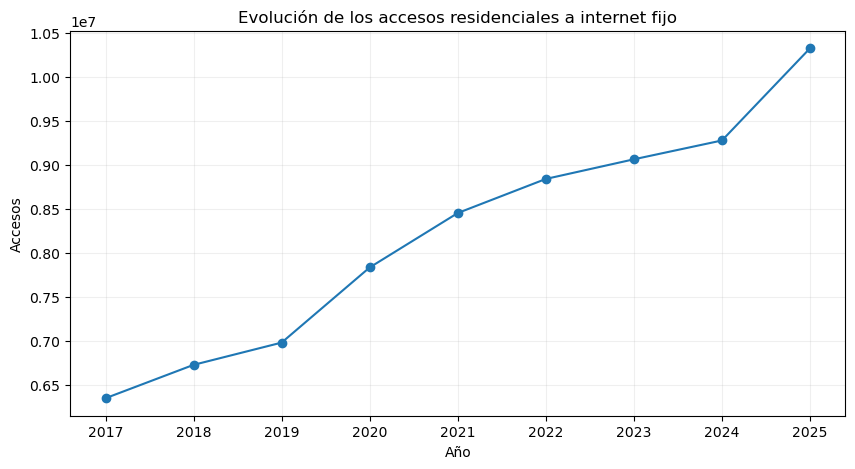

In [5]:
plt.figure(figsize=(10, 5))

plt.plot(
    accesos_q4["ANNO"],
    accesos_q4["ACCESOS"],
    marker="o"
)

plt.title("Evolución de los accesos residenciales a internet fijo")
plt.xlabel("Año")
plt.ylabel("Accesos")
plt.grid(alpha=0.2)

plt.show()

In [6]:
inicio = accesos_q4.loc[accesos_q4["ANNO"] == 2017, "ACCESOS"].iloc[0]
fin = accesos_q4.loc[accesos_q4["ANNO"] == 2025, "ACCESOS"].iloc[0]

crecimiento = (fin / inicio - 1) * 100

inicio, fin, crecimiento

(6352946, 10325111, 62.5247719719324)

dónde estuvo realmente el crecimiento

In [8]:
crecimiento_nacional = (
    accesos_q4.loc[accesos_q4["ANNO"] == 2025, "ACCESOS"].iloc[0]
    - accesos_q4.loc[accesos_q4["ANNO"] == 2017, "ACCESOS"].iloc[0]
)

crecimiento_nacional

3972165

In [9]:
municipal_q4 = (
    df_q4[
        df_q4["SEGMENTO"].str.startswith("Residencial")
    ]
    .groupby(
        [
            "ID_MUNICIPIO",
            "MUNICIPIO",
            "ID_DEPARTAMENTO",
            "DEPARTAMENTO",
            "ANNO"
        ],
        as_index=False
    )["ACCESOS"]
    .sum()
)

municipios_pivot = (
    municipal_q4
    .pivot_table(
        index=[
            "ID_MUNICIPIO",
            "MUNICIPIO",
            "ID_DEPARTAMENTO",
            "DEPARTAMENTO"
        ],
        columns="ANNO",
        values="ACCESOS",
        fill_value=0
    )
    .reset_index()
)

municipios_pivot.columns.name = None

municipios_pivot = municipios_pivot.rename(
    columns={
        2017: "ACCESOS_2017",
        2025: "ACCESOS_2025"
    }
)

ranking_municipios = municipios_pivot[
    (municipios_pivot["ACCESOS_2017"] > 0) &
    (municipios_pivot["ACCESOS_2025"] > 0)
].copy()

ranking_municipios["CAMBIO_ABSOLUTO"] = (
    ranking_municipios["ACCESOS_2025"]
    - ranking_municipios["ACCESOS_2017"]
)

ranking_municipios["CAMBIO_%"] = (
    ranking_municipios["CAMBIO_ABSOLUTO"]
    / ranking_municipios["ACCESOS_2017"]
) * 100

In [10]:
ranking_municipios["CAMBIO_ABSOLUTO"].sum()

2656733.0

In [11]:
crecimiento_nacional = (
    accesos_q4.loc[accesos_q4["ANNO"] == 2025, "ACCESOS"].iloc[0]
    - accesos_q4.loc[accesos_q4["ANNO"] == 2017, "ACCESOS"].iloc[0]
)

crecimiento_nacional

3972165

In [12]:
ranking_municipios["APORTE_CRECI_NACIONAL_%"] = (
    ranking_municipios["CAMBIO_ABSOLUTO"]
    / crecimiento_nacional
) * 100

In [13]:
ranking_municipios.sort_values(
    "APORTE_CRECI_NACIONAL_%",
    ascending=False
)[[
    "MUNICIPIO",
    "DEPARTAMENTO",
    "CAMBIO_ABSOLUTO",
    "APORTE_CRECI_NACIONAL_%"
]].head(20)

,MUNICIPIO,DEPARTAMENTO,CAMBIO_ABSOLUTO,APORTE_CRECI_NACIONAL_%
0,MEDELLÍN,ANTIOQUIA,"255,935.00",6.44
158,CARTAGENA,BOLÍVAR,"120,100.00",3.02
579,SOACHA,CUNDINAMARCA,"106,536.00",2.68
1050,IBAGUÉ,TOLIMA,"97,271.00",2.45
1099,CALI,VALLE DEL CAUCA,"96,916.00",2.44
133,BARRANQUILLA,ATLÁNTICO,"84,883.00",2.14
18,BELLO,ANTIOQUIA,"81,427.00",2.05
696,SANTA MARTA,MAGDALENA,"54,749.00",1.38
919,PEREIRA,RISARALDA,"48,140.00",1.21
434,VALLEDUPAR,CESAR,"46,706.00",1.18


In [15]:
crecimiento_residencial = (
    residenciales_q4
    .groupby("ANNO")["ACCESOS"]
    .sum()
)

crecimiento_residencial

ANNO
2017    5760591
2018    6091471
2019    6355385
2020    7206429
2021    7706886
2022    7922396
2023    8135705
2024    8325462
2025    9274043
Name: ACCESOS, dtype: int64

In [16]:
crecimiento_residencial.loc[2025] - crecimiento_residencial.loc[2017]

3513452

In [17]:
crecimiento_residencial.loc[2025] - crecimiento_residencial.loc[2017] - ranking_municipios["CAMBIO_ABSOLUTO"].sum()

856719.0

In [19]:
# Comparar crecimiento nacional vs crecimiento municipal
crecimiento_nacional = (
    residenciales_q4
    .groupby("ANNO")["ACCESOS"]
    .sum()
)

crecimiento_municipal = (
    municipal_q4
    .groupby("ANNO")["ACCESOS"]
    .sum()
)

comparacion = pd.DataFrame({
    "NACIONAL": crecimiento_nacional,
    "MUNICIPAL": crecimiento_municipal
})

comparacion["DIFERENCIA"] = (
    comparacion["NACIONAL"] - comparacion["MUNICIPAL"]
)

comparacion

,NACIONAL,MUNICIPAL,DIFERENCIA
ANNO,,,
2017,5760591,5760591,0
2018,6091471,6091471,0
2019,6355385,6355385,0
2020,7206429,7206429,0
2021,7706886,7706886,0
2022,7922396,7922396,0
2023,8135705,8135705,0
2024,8325462,8325462,0
2025,9274043,9274043,0


2. ¿Qué diferencia existe entre cabeceras y zonas rurales?

¿Qué brechas existen entre las cabeceras municipales y las zonas rurales en el acceso a internet?

3. ¿Qué territorios presentan las mayores brechas?

¿Qué territorios presentan los menores niveles de acceso a internet y cuáles concentran las mayores brechas territoriales?

4. ¿Qué cambios han experimentado los territorios con mayor crecimiento de conectividad?

¿Qué patrones de crecimiento, retroceso y recuperación de la conectividad se observan en los territorios colombianos?

5. ¿La conectividad se relaciona con otras variables socioeconómicas?

¿Qué relación existe entre el nivel de conectividad y las condiciones socioeconómicas de los territorios?

6. ¿Las personas conectadas utilizan internet de manera diferente?

¿Existen diferencias territoriales en la forma en que las personas utilizan internet?

7. ¿Existe una diferencia territorial en el uso de herramientas de inteligencia artificial?

¿Existe una brecha territorial en el uso de herramientas de inteligencia artificial?

8. ¿Podemos encontrar evidencia de que la expansión de la conectividad estuvo acompañada de cambios económicos o sociales?

¿Los territorios que experimentaron mayores cambios en conectividad también presentaron cambios en indicadores económicos y sociales?